In [ ]:
# we need to run on a py file instead of a jupyter notebook otherwise multiprocessing will not work properly
from agent import Agent, pit
from model_files.SLPolicyValueGPU import SLPolicyValueNetwork
import torch
import chess


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = SLPolicyValueNetwork().to(device)
model1.load_state_dict(torch.load("LGB70k_stockfish.pth", map_location=torch.device("cuda"))["model"])
agent = Agent(policy_value_network=model1, c_puct=0.5, dirichlet_alpha=0.3, dirichlet_epsilon=0.3)
# epsilon is set to 0 for no noise

mcts_policy_temp = 1.0 #setting temp to 1 means no temperature (temperature for policy)
mcts_temp = 0.1 # <1 means we boost the uct scores of top moves
sims = 3000

move: d2d4, count: 247.00000, ev: 0.08739, policy logit: 18.63639
move: c2c4, count: 227.00000, ev: 0.09358, policy logit: 17.04155
move: e2e4, count: 219.00000, ev: 0.08543, policy logit: 16.91628
move: b2b3, count: 179.00000, ev: 0.08718, policy logit: 13.49989
move: g1f3, count: 172.00000, ev: 0.08691, policy logit: 13.26203
move: e2e3, count: 161.00000, ev: 0.09145, policy logit: 11.63324
move: g2g3, count: 156.00000, ev: 0.09241, policy logit: 11.57947
move: c2c3, count: 150.00000, ev: 0.09065, policy logit: 11.17011
move: d2d3, count: 148.00000, ev: 0.08831, policy logit: 10.98546
move: b1c3, count: 136.00000, ev: 0.08972, policy logit: 10.01718
move: b2b4, count: 134.00000, ev: 0.08421, policy logit: 9.91124
move: f2f4, count: 130.00000, ev: 0.07913, policy logit: 9.85358
move: a2a3, count: 129.00000, ev: 0.07839, policy logit: 9.60037
move: h2h3, count: 126.00000, ev: 0.08814, policy logit: 9.43565
move: b1a3, count: 125.00000, ev: 0.09773, policy logit: 8.93580
move: a2a4, cou

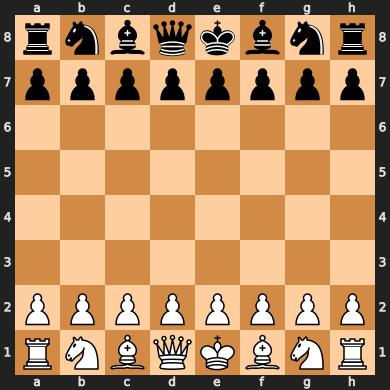

In [70]:
# Test evaluations

# should be about equal
board = chess.Board()
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: d3e2, count: 128.00000, ev: 0.83623, policy logit: 13.15021
move: d3d5, count: 126.00000, ev: 0.84111, policy logit: 12.89835
move: d3e4, count: 125.00000, ev: 0.82702, policy logit: 12.57771
move: d3c4, count: 125.00000, ev: 0.81546, policy logit: 12.76207
move: d3g6, count: 116.00000, ev: 0.75238, policy logit: 12.08545
move: d3e3, count: 116.00000, ev: 0.84195, policy logit: 11.73104
move: d3d2, count: 115.00000, ev: 0.84530, policy logit: 11.30368
move: d3f3, count: 113.00000, ev: 0.83834, policy logit: 11.30051
move: d3d4, count: 112.00000, ev: 0.82950, policy logit: 11.19556
move: d3h3, count: 110.00000, ev: 0.84972, policy logit: 10.79024
move: a1a2, count: 109.00000, ev: 0.82842, policy logit: 11.13303
move: d3d7, count: 108.00000, ev: 0.79160, policy logit: 10.77159
move: d3b5, count: 108.00000, ev: 0.82113, policy logit: 11.06178
move: d3a3, count: 108.00000, ev: 0.81096, policy logit: 11.02596
move: d3c3, count: 107.00000, ev: 0.83102, policy logit: 10.60985
move: d3f1

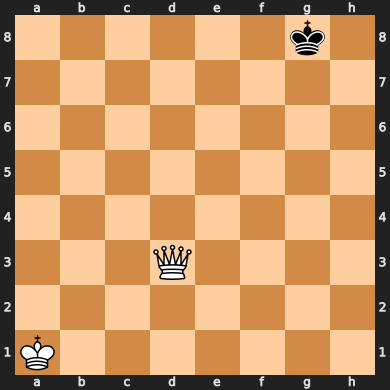

In [71]:
board = chess.Board("6k1/8/8/8/8/3Q4/8/K7 w - - 0 1")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: g8h8, count: 1953.00000, ev: -0.15657, policy logit: 1.74192
move: g8g7, count: 1044.00000, ev: -0.13596, policy logit: -0.02054
move: g8f8, count: 1.00000, ev: -0.95993, policy logit: -1.52236
move: g8f7, count: 1.00000, ev: -0.98557, policy logit: -1.66956
final eval:  -0.1565732356515014
tested 4 moves out of  4
g8h8
initial evaluation:  0.0446881465613842


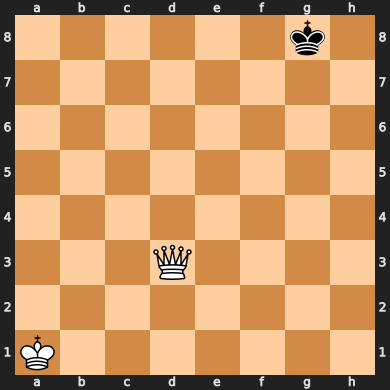

In [51]:
# should be negative (losing)
board = chess.Board("6k1/8/8/8/8/3Q4/8/K7 b - - 0 1")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: c3d5, count: 691.00000, ev: 0.93548, policy logit: 15.44306
move: g1f3, count: 166.00000, ev: 0.69178, policy logit: 4.72298
move: d1e2, count: 165.00000, ev: 0.43130, policy logit: 6.61099
move: d2d3, count: 155.00000, ev: 0.68532, policy logit: 4.17905
move: h2h3, count: 128.00000, ev: 0.51103, policy logit: 4.52350
move: d2d4, count: 118.00000, ev: 0.67447, policy logit: 3.36079
move: g1e2, count: 109.00000, ev: 0.39169, policy logit: 4.56195
move: f2f3, count: 100.00000, ev: 0.46588, policy logit: 3.75860
move: e1e2, count: 99.00000, ev: 0.23156, policy logit: 4.77830
move: b2b4, count: 99.00000, ev: 0.51578, policy logit: 3.25778
move: f2f4, count: 96.00000, ev: 0.55288, policy logit: 3.08683
move: g1h3, count: 95.00000, ev: 0.37563, policy logit: 4.13017
move: c3b5, count: 88.00000, ev: 0.28599, policy logit: 4.26367
move: b2b3, count: 75.00000, ev: 0.27963, policy logit: 3.54186
move: d1f3, count: 74.00000, ev: 0.28091, policy logit: 3.24695
move: f1c4, count: 70.00000, ev

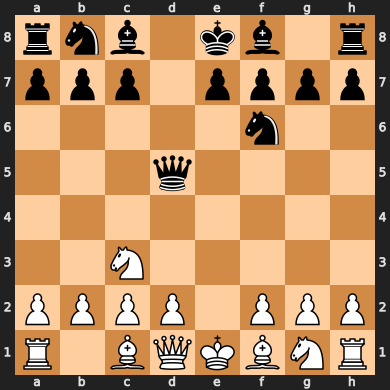

In [52]:
# should be positive (c3d5, somewhat winning)
board = chess.Board("rnb1kb1r/ppp1pppp/5n2/3q4/8/2N5/PPPP1PPP/R1BQKBNR w KQkq - 2 4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: d8d4, count: 754.00000, ev: 0.78729, policy logit: 13.78894
move: g7g6, count: 174.00000, ev: 0.38829, policy logit: 5.11511
move: b8c6, count: 159.00000, ev: 0.45616, policy logit: 4.19752
move: f6e4, count: 151.00000, ev: 0.31810, policy logit: 5.12489
move: d8d6, count: 149.00000, ev: 0.43937, policy logit: 3.92249
move: d8d7, count: 136.00000, ev: 0.18948, policy logit: 5.46954
move: d8d5, count: 111.00000, ev: 0.24417, policy logit: 3.79352
move: c8g4, count: 111.00000, ev: 0.29603, policy logit: 3.65213
move: f6g4, count: 106.00000, ev: 0.11380, policy logit: 4.47018
move: h8g8, count: 90.00000, ev: 0.26493, policy logit: 2.93686
move: f6h5, count: 88.00000, ev: 0.17199, policy logit: 3.27372
move: g7g5, count: 85.00000, ev: 0.22793, policy logit: 2.96990
move: b7b5, count: 84.00000, ev: 0.12413, policy logit: 3.36300
move: b7b6, count: 82.00000, ev: 0.41704, policy logit: 2.19361
move: f6d5, count: 74.00000, ev: -0.01411, policy logit: 3.51413
move: c8e6, count: 72.00000, 

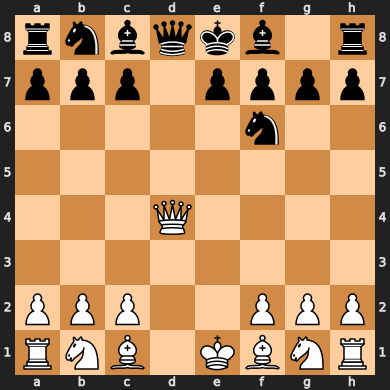

In [53]:
# should be positive (d8d4, somewhat winning)
board = chess.Board("rnbqkb1r/ppp1pppp/5n2/8/3Q4/8/PPP2PPP/RNB1KBNR b KQkq - 2 4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: g1f3, count: 182.00000, ev: -0.35460, policy logit: 8.67989
move: c1e3, count: 141.00000, ev: -0.43045, policy logit: 7.19874
move: c2c3, count: 140.00000, ev: -0.50493, policy logit: 7.60423
move: b1c3, count: 137.00000, ev: -0.56223, policy logit: 7.80400
move: h2h4, count: 125.00000, ev: -0.81258, policy logit: 8.78381
move: h2h3, count: 124.00000, ev: -0.76859, policy logit: 8.50259
move: f1b5, count: 116.00000, ev: -0.92715, policy logit: 8.76709
move: f2f3, count: 115.00000, ev: -0.80027, policy logit: 7.73532
move: b1a3, count: 111.00000, ev: -0.77923, policy logit: 7.51194
move: g1e2, count: 110.00000, ev: -0.67515, policy logit: 6.56497
move: a2a4, count: 110.00000, ev: -0.81861, policy logit: 7.78585
move: f1a6, count: 107.00000, ev: -0.66400, policy logit: 6.59984
move: c2c4, count: 106.00000, ev: -0.70935, policy logit: 6.84756
move: f1c4, count: 105.00000, ev: -0.49572, policy logit: 5.73390
move: b2b3, count: 103.00000, ev: -0.85877, policy logit: 7.35838
move: g1h3

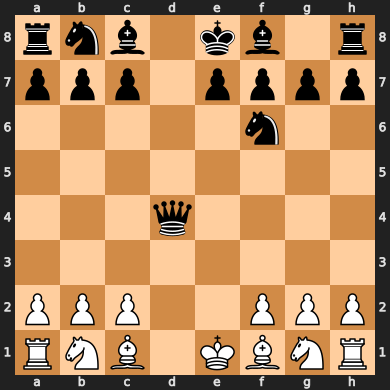

In [54]:
# should be negative (after d8d4, somewhat losing)
board = chess.Board("rnb1kb1r/ppp1pppp/5n2/8/3q4/8/PPP2PPP/RNB1KBNR w KQkq - 0 5")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: e6e7, count: 886.00000, ev: 0.14658, policy logit: 5.70094
move: h2g3, count: 399.00000, ev: -0.26728, policy logit: 8.75727
move: h6g6, count: 189.00000, ev: -0.46630, policy logit: 5.29668
move: h6g5, count: 161.00000, ev: -0.56913, policy logit: 5.60854
move: h6h7, count: 150.00000, ev: -0.95049, policy logit: 7.93214
move: h6f8, count: 145.00000, ev: -0.98475, policy logit: 7.80211
move: h6h5, count: 136.00000, ev: -0.44685, policy logit: 3.74747
move: h6d2, count: 132.00000, ev: -0.51438, policy logit: 3.98453
move: h6g7, count: 130.00000, ev: -0.98127, policy logit: 6.92991
move: h6f6, count: 119.00000, ev: -0.35262, policy logit: 2.86183
move: b3d4, count: 112.00000, ev: -0.50111, policy logit: 3.27802
move: h6f4, count: 110.00000, ev: -0.53771, policy logit: 3.11729
move: h6e3, count: 106.00000, ev: -0.57318, policy logit: 3.43504
move: h2h4, count: 92.00000, ev: -0.55626, policy logit: 2.75935
move: e6e5, count: 80.00000, ev: -0.73381, policy logit: 3.13850
move: h6h4, c

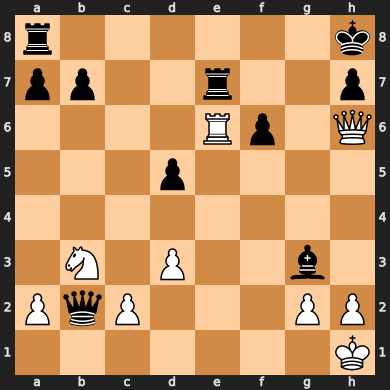

In [55]:
# should be positive (e6e7, somewhat winning)
board = chess.Board("r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2b1/PqP3PP/7K w - - 0 25")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: d6c6, count: 502.00000, ev: 0.17891, policy logit: 8.10180
move: d7c6, count: 266.00000, ev: 0.18623, policy logit: 2.91133
move: d6b4, count: 249.00000, ev: 0.03062, policy logit: 4.58504
move: d6d5, count: 186.00000, ev: -0.10186, policy logit: 4.15161
move: d6c7, count: 175.00000, ev: -0.01301, policy logit: 3.08540
move: d6d4, count: 163.00000, ev: 0.08959, policy logit: 2.07877
move: d6c5, count: 157.00000, ev: -0.16580, policy logit: 4.22628
move: d7g4, count: 143.00000, ev: 0.05185, policy logit: 1.84006
move: d7h3, count: 141.00000, ev: -0.01963, policy logit: 2.37928
move: d8f8, count: 135.00000, ev: -0.11546, policy logit: 2.88650
move: d7e6, count: 132.00000, ev: 0.15397, policy logit: 1.13840
move: d8c8, count: 125.00000, ev: -0.09374, policy logit: 2.54797
move: d7a4, count: 116.00000, ev: 0.03726, policy logit: 1.53890
move: d6e7, count: 113.00000, ev: -0.51725, policy logit: 4.66499
move: d6b6, count: 88.00000, ev: 0.02050, policy logit: 1.20793
move: d6a3, count: 

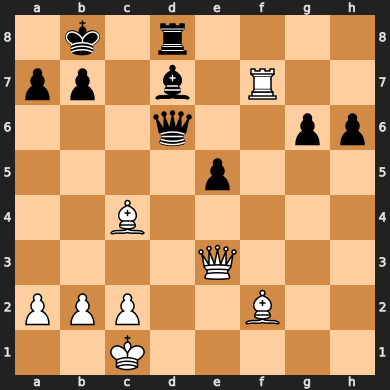

In [56]:
# should be positive (d6d1, mate in 3)
board = chess.Board("1k1r4/pp1b1R2/3q2pp/4p3/2B5/4Q3/PPP2B2/2K5 b - - 0 1")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: d7g4, count: 601.00000, ev: -0.34669, policy logit: 7.45650
move: d7e6, count: 588.00000, ev: -0.09076, policy logit: 2.98277
move: d7c6, count: 439.00000, ev: -0.23232, policy logit: 3.23222
move: d7h3, count: 438.00000, ev: -0.29714, policy logit: 5.00638
move: d7f5, count: 297.00000, ev: -0.32735, policy logit: 2.73947
move: d8c8, count: 162.00000, ev: -0.63710, policy logit: 3.51142
move: d7a4, count: 162.00000, ev: -0.34943, policy logit: 1.53299
move: d8f8, count: 78.00000, ev: -0.70487, policy logit: 1.65145
move: b8c8, count: 55.00000, ev: -0.79187, policy logit: 1.34796
move: a7a6, count: 48.00000, ev: -0.81750, policy logit: 1.19669
move: g6g5, count: 31.00000, ev: -0.72032, policy logit: 0.57895
move: d7b5, count: 29.00000, ev: -0.41347, policy logit: -0.07130
move: h6h5, count: 24.00000, ev: -0.65503, policy logit: 0.27257
move: e5e4, count: 24.00000, ev: -0.70964, policy logit: 0.34713
move: d7c8, count: 18.00000, ev: -0.55850, policy logit: 0.11090
move: d8g8, count

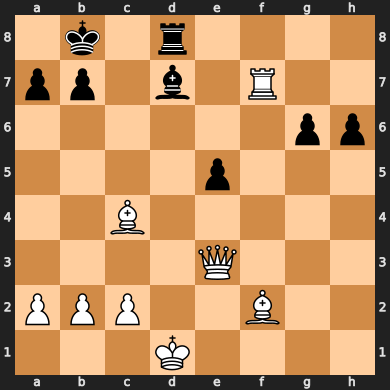

In [57]:
# should be positive (d7g4, mate in 2)
board = chess.Board("1k1r4/pp1b1R2/6pp/4p3/2B5/4Q3/PPP2B2/3K4 b - - 0 2")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: d1c1, count: 1674.00000, ev: 0.62034, policy logit: 2.29382
move: d1e1, count: 1325.00000, ev: 0.51629, policy logit: 6.29049
final eval:  0.6203438558915065
tested 2 moves out of  2
d1c1
initial evaluation:  0.959551215171814


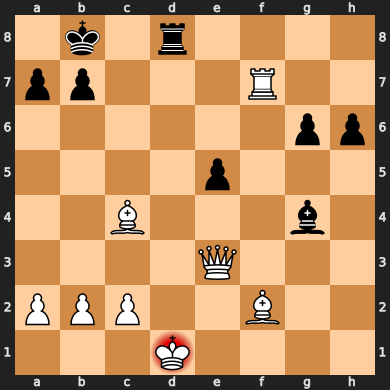

In [58]:
# should be negative (d7g4, mate in 1 coming)
board = chess.Board("1k1r4/pp3R2/6pp/4p3/2B3b1/4Q3/PPP2B2/3K4 w - - 1 3")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: g4f3, count: 427.00000, ev: -0.37793, policy logit: 5.75265
move: d8d4, count: 335.00000, ev: -0.44991, policy logit: 4.67236
move: d8c8, count: 255.00000, ev: -0.50517, policy logit: 3.86385
move: d8d7, count: 218.00000, ev: -0.54139, policy logit: 3.71760
move: g4d1, count: 201.00000, ev: -0.54609, policy logit: 3.51336
move: d8d5, count: 199.00000, ev: -0.43071, policy logit: 1.99983
move: g4f5, count: 182.00000, ev: -0.63357, policy logit: 4.05821
move: d8f8, count: 181.00000, ev: -0.70701, policy logit: 4.04013
move: d8d6, count: 140.00000, ev: -0.50415, policy logit: 1.91220
move: d8e8, count: 137.00000, ev: -0.75594, policy logit: 3.50108
move: g4h5, count: 136.00000, ev: -0.57547, policy logit: 2.32944
move: g4e6, count: 133.00000, ev: -0.60999, policy logit: 2.50157
move: d8d2, count: 104.00000, ev: -0.35435, policy logit: 0.33544
move: g4h3, count: 86.00000, ev: -0.63750, policy logit: 1.40973
move: a7a6, count: 82.00000, ev: -0.62184, policy logit: 1.10557
move: g4e2, 

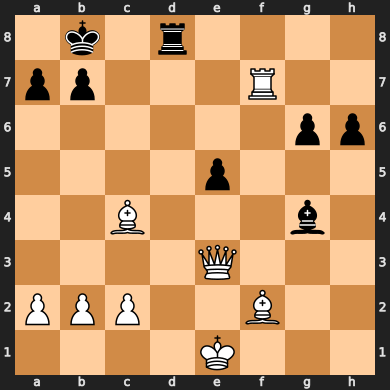

In [59]:
# should be positive (d8d1, mate in 1)
board = chess.Board("1k1r4/pp3R2/6pp/4p3/2B3b1/4Q3/PPP2B2/4K3 b - - 2 3")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

move: f6h5, count: 270.00000, ev: 0.47016, policy logit: 5.16093
move: f6g4, count: 263.00000, ev: 0.30721, policy logit: 7.11966
move: f6e4, count: 249.00000, ev: 0.29063, policy logit: 6.69073
move: f6g8, count: 241.00000, ev: 0.28713, policy logit: 6.71568
move: f6d5, count: 233.00000, ev: 0.17879, policy logit: 7.30660
move: g7g6, count: 159.00000, ev: -0.08780, policy logit: 6.83054
move: c5c4, count: 132.00000, ev: -0.22843, policy logit: 6.74696
move: g7g5, count: 114.00000, ev: 0.05974, policy logit: 4.24943
move: a7a6, count: 110.00000, ev: -0.23028, policy logit: 5.49539
move: b7b6, count: 108.00000, ev: -0.41940, policy logit: 6.54792
move: c6e5, count: 106.00000, ev: 0.38553, policy logit: 2.00014
move: e7e6, count: 102.00000, ev: -0.25084, policy logit: 5.49683
move: a8b8, count: 96.00000, ev: -0.11517, policy logit: 4.39591
move: d7d5, count: 95.00000, ev: -0.27520, policy logit: 5.01645
move: c6d4, count: 89.00000, ev: -0.55370, policy logit: 6.06329
move: h8g8, count: 8

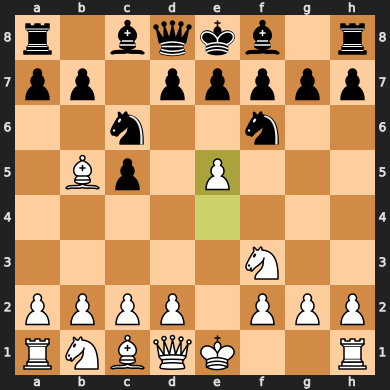

In [60]:
#why does it take on e5??
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board


move: b5c6, count: 262.00000, ev: 0.49894, policy logit: 6.98934
move: b5c4, count: 255.00000, ev: 0.57989, policy logit: 6.41583
move: d2d4, count: 216.00000, ev: 0.26551, policy logit: 8.43577
move: e1g1, count: 199.00000, ev: 0.34931, policy logit: 6.89558
move: c2c4, count: 190.00000, ev: 0.17615, policy logit: 8.17662
move: b1c3, count: 187.00000, ev: 0.30249, policy logit: 6.54791
move: d2d3, count: 169.00000, ev: 0.33915, policy logit: 6.12966
move: b2b3, count: 138.00000, ev: 0.15709, policy logit: 5.96417
move: c2c3, count: 124.00000, ev: 0.05801, policy logit: 6.00298
move: h1g1, count: 95.00000, ev: 0.00329, policy logit: 4.76364
move: f3g5, count: 94.00000, ev: -0.06538, policy logit: 4.92807
move: b1a3, count: 91.00000, ev: -0.11181, policy logit: 4.94626
move: h2h3, count: 84.00000, ev: -0.04954, policy logit: 4.19394
move: b5a6, count: 77.00000, ev: 0.15477, policy logit: 3.12396
move: a2a4, count: 75.00000, ev: -0.37475, policy logit: 5.19144
move: b2b4, count: 72.00000

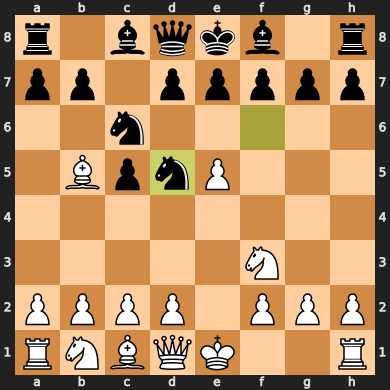

In [61]:
# clearly worse for black?
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
board.push_uci("f6d5")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board


move: d5f4, count: 439.00000, ev: 0.75707, policy logit: 8.33052
move: d5b4, count: 299.00000, ev: 0.38945, policy logit: 10.27011
move: d5c7, count: 270.00000, ev: 0.44931, policy logit: 8.52315
move: e7e6, count: 162.00000, ev: -0.01716, policy logit: 8.25513
move: d5b6, count: 161.00000, ev: -0.01706, policy logit: 8.31564
move: d5c3, count: 131.00000, ev: 0.12025, policy logit: 5.24067
move: d5e3, count: 128.00000, ev: 0.20986, policy logit: 4.91053
move: d5f6, count: 121.00000, ev: 0.03782, policy logit: 5.53313
move: a7a6, count: 104.00000, ev: -0.16546, policy logit: 5.95198
move: a7a5, count: 97.00000, ev: -0.31143, policy logit: 6.01515
move: f7f5, count: 87.00000, ev: -0.25101, policy logit: 5.22052
move: c6b4, count: 85.00000, ev: -0.41317, policy logit: 6.06026
move: d7d6, count: 82.00000, ev: -0.41789, policy logit: 5.93568
move: b7b6, count: 80.00000, ev: -0.45936, policy logit: 5.52465
move: c6e5, count: 79.00000, ev: 0.14361, policy logit: 3.09263
move: c6d4, count: 76.

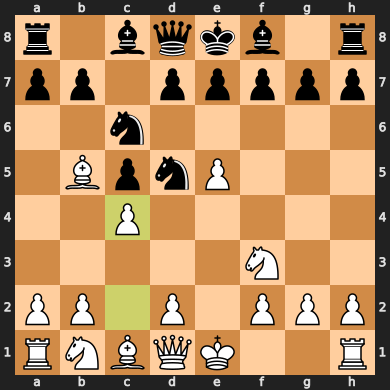

In [62]:
# clearly worse for black?
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
board.push_uci("f6d5")
board.push_uci("c2c4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board


move: b1c3, count: 362.00000, ev: 0.36244, policy logit: 7.39603
move: d2d4, count: 352.00000, ev: 0.22186, policy logit: 9.38020
move: b5c6, count: 306.00000, ev: 0.36537, policy logit: 5.32635
move: e1g1, count: 238.00000, ev: 0.09406, policy logit: 7.33538
move: a2a3, count: 205.00000, ev: -0.26180, policy logit: 9.72962
move: b2b3, count: 163.00000, ev: -0.03142, policy logit: 5.69839
move: a2a4, count: 121.00000, ev: -0.52956, policy logit: 7.22225
move: f3d4, count: 110.00000, ev: -0.61858, policy logit: 6.90202
move: f3g5, count: 109.00000, ev: -0.36024, policy logit: 5.61005
move: b1a3, count: 107.00000, ev: -0.40235, policy logit: 5.23318
move: h1g1, count: 98.00000, ev: -0.25055, policy logit: 4.31671
move: d2d3, count: 89.00000, ev: -0.00092, policy logit: 2.68327
move: h2h4, count: 82.00000, ev: -0.32675, policy logit: 3.74032
move: d1e2, count: 73.00000, ev: -0.35662, policy logit: 3.52928
move: h2h3, count: 72.00000, ev: -0.26876, policy logit: 3.18945
move: g2g3, count: 

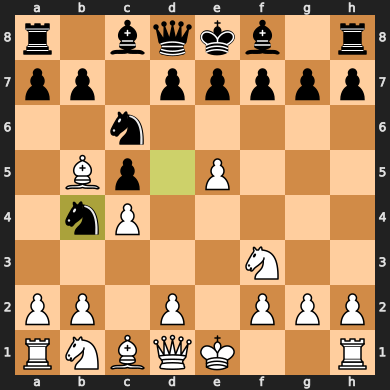

In [63]:
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
board.push_uci("f6d5")
board.push_uci("c2c4")
board.push_uci("d5b4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board


move: e2f3, count: 697.00000, ev: 0.37030, policy logit: 4.38900
move: d6e7, count: 588.00000, ev: 0.03515, policy logit: 11.04316
move: b4c3, count: 165.00000, ev: -0.38048, policy logit: 5.41392
move: e2c4, count: 154.00000, ev: -0.26216, policy logit: 4.20733
move: d6d7, count: 153.00000, ev: -0.25033, policy logit: 3.97819
move: b3a3, count: 123.00000, ev: -0.28671, policy logit: 3.24155
move: b3d1, count: 119.00000, ev: -0.29058, policy logit: 3.11925
move: e2d3, count: 113.00000, ev: -0.42572, policy logit: 3.48042
move: g2g3, count: 112.00000, ev: -0.27203, policy logit: 2.96860
move: g1h1, count: 107.00000, ev: -0.35190, policy logit: 3.09374
move: b3c3, count: 80.00000, ev: -0.24235, policy logit: 1.92903
move: b3a2, count: 79.00000, ev: -0.19408, policy logit: 1.50937
move: b4c5, count: 76.00000, ev: -0.07382, policy logit: 1.03351
move: b3c4, count: 71.00000, ev: -0.54228, policy logit: 2.58718
move: b6d7, count: 63.00000, ev: -0.04712, policy logit: 0.62185
move: b3e3, coun

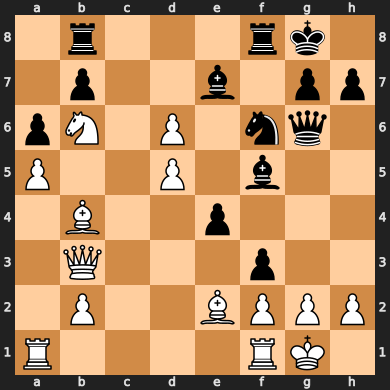

In [64]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

move: d6e7, count: 537.00000, ev: 0.50517, policy logit: 15.58385
move: f3g3, count: 272.00000, ev: 0.59103, policy logit: 5.79828
move: f3h3, count: 226.00000, ev: 0.51720, policy logit: 5.19495
move: a1c1, count: 188.00000, ev: 0.44280, policy logit: 4.83294
move: f3f4, count: 179.00000, ev: 0.13442, policy logit: 7.27839
move: b4c3, count: 163.00000, ev: 0.29118, policy logit: 5.11548
move: g2g3, count: 153.00000, ev: 0.20096, policy logit: 5.68645
move: d6d7, count: 143.00000, ev: 0.06627, policy logit: 5.90225
move: a1d1, count: 127.00000, ev: 0.40820, policy logit: 3.18116
move: f3f5, count: 123.00000, ev: -0.01676, policy logit: 5.73351
move: f3g4, count: 116.00000, ev: 0.10691, policy logit: 4.59472
move: f3f6, count: 99.00000, ev: 0.25725, policy logit: 3.08433
move: g2g4, count: 91.00000, ev: 0.04489, policy logit: 3.69007
move: g1h1, count: 90.00000, ev: 0.18228, policy logit: 3.22567
move: f3h5, count: 87.00000, ev: -0.23146, policy logit: 4.78051
move: f3b3, count: 81.0000

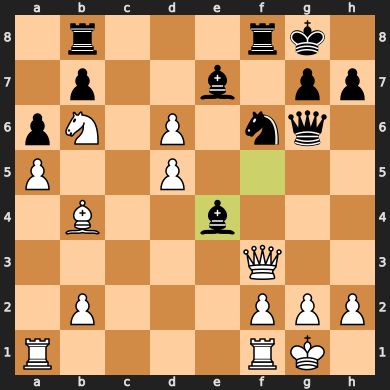

In [65]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

move: e4f3, count: 1311.00000, ev: 0.22068, policy logit: 14.01804
move: g6g4, count: 188.00000, ev: -0.51622, policy logit: 6.51754
move: g6f7, count: 173.00000, ev: -0.49936, policy logit: 6.07789
move: b8d8, count: 167.00000, ev: -0.03043, policy logit: 2.21289
move: g6g5, count: 165.00000, ev: -0.26733, policy logit: 3.71558
move: g6h5, count: 148.00000, ev: -0.54121, policy logit: 5.40613
move: e4d5, count: 145.00000, ev: -0.46020, policy logit: 4.51189
move: e7d8, count: 110.00000, ev: -0.13188, policy logit: 1.75621
move: g8h8, count: 103.00000, ev: -0.20328, policy logit: 2.04398
move: f6g4, count: 95.00000, ev: -0.12904, policy logit: 1.42644
move: e4c2, count: 88.00000, ev: -0.74669, policy logit: 3.97455
move: e4d3, count: 82.00000, ev: -0.53190, policy logit: 2.70343
move: f8f7, count: 69.00000, ev: -0.03507, policy logit: 0.63371
move: g6g3, count: 49.00000, ev: -0.44861, policy logit: 1.08369
move: g6f5, count: 42.00000, ev: -0.26479, policy logit: 0.66614
move: b8c8, cou

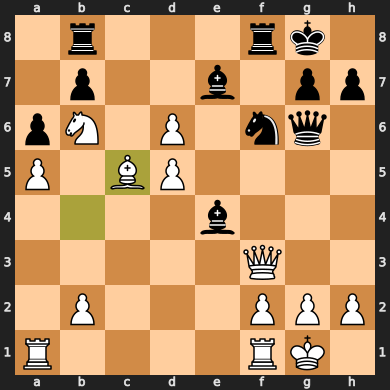

In [66]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
board.push_uci("b4c5")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

move: d6e7, count: 1162.00000, ev: -0.23165, policy logit: 14.23106
move: g2g3, count: 427.00000, ev: -0.26408, policy logit: 4.37451
move: b6d7, count: 368.00000, ev: -0.19512, policy logit: 2.47430
move: d6d7, count: 367.00000, ev: -0.50823, policy logit: 8.14511
move: a1c1, count: 256.00000, ev: -0.19704, policy logit: 1.24786
move: c5d4, count: 132.00000, ev: -0.32102, policy logit: 1.34845
move: b6c4, count: 115.00000, ev: -0.21463, policy logit: 0.48334
move: c5b4, count: 102.00000, ev: -0.41471, policy logit: 1.24868
move: g2g4, count: 54.00000, ev: -0.50846, policy logit: 0.81737
move: h2h3, count: 5.00000, ev: -0.55507, policy logit: -0.03256
move: b6a4, count: 1.00000, ev: -0.13062, policy logit: -7.05179
move: c5e3, count: 1.00000, ev: 0.80660, policy logit: -1.55994
move: c5a3, count: 1.00000, ev: -0.21851, policy logit: -10.65963
move: g1h1, count: 1.00000, ev: -0.38514, policy logit: -0.61448
move: f1e1, count: 1.00000, ev: 0.75184, policy logit: -1.19728
move: f1d1, coun

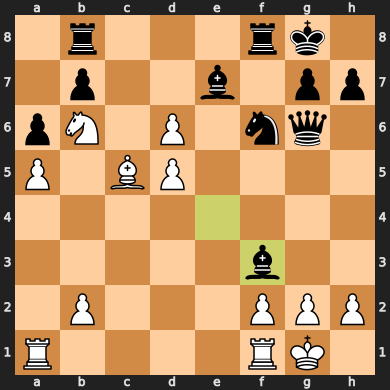

In [67]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
board.push_uci("b4c5")
board.push_uci("e4f3")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

move: g6g2, count: 1675.00000, ev: 1.00000, policy logit: 7.38796
move: e7d6, count: 203.00000, ev: 0.25121, policy logit: 5.95447
move: f3g2, count: 183.00000, ev: -0.07359, policy logit: 8.56137
move: g6c2, count: 134.00000, ev: -0.10403, policy logit: 5.85487
move: g6g4, count: 116.00000, ev: -0.16296, policy logit: 5.50763
move: f6g4, count: 90.00000, ev: 0.05740, policy logit: 2.95814
move: g6h5, count: 82.00000, ev: -0.20957, policy logit: 3.93150
move: f3e4, count: 79.00000, ev: -0.25581, policy logit: 4.01005
move: g6f7, count: 77.00000, ev: -0.20809, policy logit: 3.84241
move: e7d8, count: 58.00000, ev: -0.04890, policy logit: 2.55572
move: g6e4, count: 54.00000, ev: 0.02886, policy logit: 1.95830
move: f6e4, count: 53.00000, ev: -0.33656, policy logit: 2.87937
move: f6h5, count: 46.00000, ev: 0.21056, policy logit: 1.08054
move: h7h5, count: 40.00000, ev: -0.40852, policy logit: 2.33244
move: g6f5, count: 30.00000, ev: 0.23870, policy logit: 0.53950
move: h7h6, count: 27.000

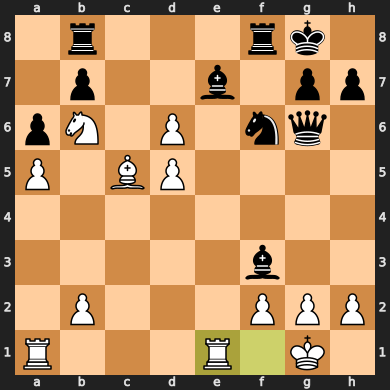

In [68]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
board.push_uci("b4c5")
board.push_uci("e4f3")
board.push_uci("f1e1")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board